# Introduction to Deep Learning
# PyTorch Tutorial

**Learning Objectives:**
- Understand what PyTorch is and why it's used in deep learning
- Master tensor operations and manipulations
- Learn automatic differentiation (autograd)
- Build and train a simple neural network

---

## What is PyTorch?

> PyTorch is an open source deep learning platform that provides a seamless path from research prototyping to production deployment.
>
> **Key Features:**
> - **Dynamic Computation Graphs**: Build graphs on-the-fly for flexibility
> - **Python-First Design**: Deep integration with Python ecosystem
> - **Strong GPU Acceleration**: Seamless CUDA support
> - **Rich Ecosystem**: Tools for computer vision, NLP, and more
>
> — *[PyTorch.org](https://pytorch.org/)*

### Why PyTorch?

PyTorch has become one of the most popular deep learning frameworks due to its:
1. **Intuitive API**: Easy to learn and use, especially for Python developers
2. **Debugging**: Standard Python debugging tools work seamlessly
3. **Research-Friendly**: Preferred by researchers for its flexibility
4. **Production-Ready**: Used in production by companies like Meta, Tesla, and more

**Resources:**
- [Official Documentation](https://pytorch.org/docs/stable/index.html)
- [PyTorch Tutorials](https://pytorch.org/tutorials/)
- [Nvidia's PyTorch Guide](https://www.nvidia.com/en-us/glossary/data-science/pytorch/)

---

## 1. Installing PyTorch

For Google Colab, PyTorch is usually pre-installed. Otherwise, install it with:

```bash
pip install torch torchvision
```

For specific installation instructions (CPU/GPU, different CUDA versions), visit: https://pytorch.org/get-started/locally/

In [1]:
# Check if PyTorch is installed
!pip install torch torchvision --quiet

## 2. Importing Libraries

Let's import the necessary libraries:

In [2]:
import torch
import numpy as np

# Check PyTorch version
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cpu
CUDA available: False


## 3. Tensors: The Building Blocks

**What is a Tensor?**

A tensor is a multi-dimensional array, similar to NumPy arrays but with additional capabilities:
- Can run on GPUs for faster computation
- Support automatic differentiation (crucial for training neural networks)

**Tensor Dimensions:**
- 0D tensor (scalar): `5`
- 1D tensor (vector): `[1, 2, 3]`
- 2D tensor (matrix): `[[1, 2], [3, 4]]`
- 3D+ tensor: Higher dimensional arrays (e.g., images, videos)

### 3.1 Creating Tensors from Python Lists

In [3]:
# Create a 2D tensor from a list
x_list = [[1, 3, 5],
          [2, 4, 6]]

x_tensor = torch.tensor(x_list)
print("Tensor:")
print(x_tensor)
print(f"\nShape: {x_tensor.shape}")        # Dimensions of the tensor
print(f"Dimension: {x_tensor.ndim}")      # Number of dimensions
print(f"Data type: {x_tensor.dtype}")     # Data type of elements
print(f"Size: {x_tensor.size()}")         # Alternative way to get shape

Tensor:
tensor([[1, 3, 5],
        [2, 4, 6]])

Shape: torch.Size([2, 3])
Dimension: 2
Data type: torch.int64
Size: torch.Size([2, 3])


### 3.2 Converting Between PyTorch and NumPy

PyTorch tensors and NumPy arrays can be easily converted between each other. They often share the same memory, so changes to one affect the other!

In [4]:
# Tensor to NumPy
x_np = x_tensor.numpy()
print("NumPy array:")
print(x_np)
print(f"Type: {type(x_np)}")

NumPy array:
[[1 3 5]
 [2 4 6]]
Type: <class 'numpy.ndarray'>


In [5]:
# NumPy to Tensor
x_tensor_back = torch.from_numpy(x_np)
print("Back to tensor:")
print(x_tensor_back)
print(f"Type: {type(x_tensor_back)}")

Back to tensor:
tensor([[1, 3, 5],
        [2, 4, 6]])
Type: <class 'torch.Tensor'>


## 4. Creating Tensors

PyTorch provides many convenient functions to create tensors with specific values or patterns.

### 4.1 Zeros and Ones

In [6]:
# Tensor filled with zeros
zero_tensor = torch.zeros(2, 3)  # 2 rows, 3 columns
print("Zeros:")
print(zero_tensor)

Zeros:
tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [7]:
# Tensor filled with ones
ones_tensor = torch.ones(3, 3)
print("Ones:")
print(ones_tensor)

Ones:
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])


### 4.2 Filled with Specific Values

In [8]:
# Tensor filled with a specific value
full_tensor = torch.full((4, 3), fill_value=6.5)
print("Filled with 6.5:")
print(full_tensor)

Filled with 6.5:
tensor([[6.5000, 6.5000, 6.5000],
        [6.5000, 6.5000, 6.5000],
        [6.5000, 6.5000, 6.5000],
        [6.5000, 6.5000, 6.5000]])


### 4.3 Random Tensors

Random tensors are commonly used for:
- Initializing neural network weights
- Creating test data
- Data augmentation

In [9]:
# Random tensor from standard normal distribution (mean=0, std=1)
random_tensor = torch.randn(2, 3)
print("Random tensor (normal distribution):")
print(random_tensor)

# Random tensor from uniform distribution [0, 1)
uniform_tensor = torch.rand(2, 3)
print("\nRandom tensor (uniform distribution):")
print(uniform_tensor)

Random tensor (normal distribution):
tensor([[ 0.1393, -0.1760,  0.8999],
        [-0.9410, -1.5276, -0.3852]])

Random tensor (uniform distribution):
tensor([[0.9942, 0.5609, 0.8941],
        [0.1197, 0.0755, 0.6889]])


### 4.4 Creating Tensors Like Another

Sometimes you want to create a new tensor with the same shape as an existing one:

In [10]:
# Create tensors with same shape as x_tensor
zeros_like = torch.zeros_like(x_tensor)
ones_like = torch.ones_like(x_tensor)
rand_like = torch.randn_like(x_tensor.float())  # Note: need float type for randn

print("Original tensor shape:", x_tensor.shape)
print("zeros_like shape:", zeros_like.shape)
print("\nRandom tensor with same shape:")
print(rand_like)

Original tensor shape: torch.Size([2, 3])
zeros_like shape: torch.Size([2, 3])

Random tensor with same shape:
tensor([[-0.1281,  0.6888,  0.4065],
        [ 0.9755, -0.6651, -0.5304]])


## 5. Device: CPU vs GPU

**Why GPUs Matter:**
- GPUs can perform thousands of operations in parallel
- Deep learning involves massive matrix operations → perfect for GPUs
- Training can be 10-100x faster on GPU vs CPU

**Important Rule:** Model and data must be on the same device!

In [11]:
# Check default device
x = torch.randn(2, 3)
print("Default device:", x.device)  # Usually 'cpu'

Default device: cpu


In [12]:
# Check if CUDA (GPU) is available and set device
print("Is CUDA available?", torch.cuda.is_available())

# Set device to GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move tensor to device
x = x.to(device)
print(f"Tensor is now on: {x.device}")

Is CUDA available? False
Using device: cpu
Tensor is now on: cpu


**Pro Tip:** When working with models:
```python
model = MyModel().to(device)  # Move model to device
data = data.to(device)         # Move data to device
output = model(data)           # Now they can work together!
```

## 6. Vectorization: Writing Efficient Code

**What is Vectorization?**

Vectorization means performing operations on entire arrays at once, rather than using loops. This is:
- **Faster**: Takes advantage of optimized low-level implementations
- **Cleaner**: Less code, easier to read
- **More Pythonic**: Follows best practices

Let's see the difference:

In [13]:
import time

# Non-vectorized approach (SLOW)
x = torch.tensor([1, 2, 3, 4, 5])
start = time.time()
for i in range(len(x)):
    x[i] = x[i] + 5
time_loop = time.time() - start
print("Non-vectorized result:", x)
print(f"Time: {time_loop:.6f} seconds")

Non-vectorized result: tensor([ 6,  7,  8,  9, 10])
Time: 0.004689 seconds


In [14]:
# Vectorized approach (FAST)
x = torch.tensor([1, 2, 3, 4, 5])
start = time.time()
x = x + 5
time_vec = time.time() - start
print("Vectorized result:", x)
print(f"Time: {time_vec:.6f} seconds")
print(f"\nSpeedup: {time_loop/time_vec:.1f}x faster!")

Vectorized result: tensor([ 6,  7,  8,  9, 10])
Time: 0.000436 seconds

Speedup: 10.8x faster!


### 6.1 Common Vector Operations

Let's implement fundamental operations that are building blocks of neural networks.

#### Dot Product

The dot product of two vectors $\mathbf{x}$ and $\mathbf{y}$ is:
$$\mathbf{x} \cdot \mathbf{y} = \sum_{i=1}^{n} x_i y_i = x_1y_1 + x_2y_2 + \cdots + x_ny_n$$

**Use cases in Deep Learning:**
- Computing similarity between vectors
- Matrix multiplication (combination of dot products)
- Attention mechanisms

In [15]:
def dot_product(x, y):
    """
    Compute dot product of two 1D tensors.
    
    Args:
        x: 1D tensor
        y: 1D tensor (same size as x)
    
    Returns:
        Scalar tensor representing the dot product
    """
    return torch.dot(x, y)

# Example
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])
result = dot_product(x, y)
print(f"x · y = {result}")
print(f"Manual calculation: 1*4 + 2*5 + 3*6 = {1*4 + 2*5 + 3*6}")

x · y = 32.0
Manual calculation: 1*4 + 2*5 + 3*6 = 32


**📝 Exercise 1: Implement Dot Product**

Implement the dot product function using PyTorch operations.

In [16]:
def PYTORCH_dot(x, y):
    """
    Dot product of two tensors.
    
    Parameters:
        x (torch.Tensor): 1D tensor
        y (torch.Tensor): 1D tensor
    
    Returns:
        torch.Tensor: Scalar result of dot product
    """
    # TODO: Implement using torch.dot() or equivalent
    # Hint: You can use torch.dot(x, y) or (x * y).sum()
    pass  # Replace with your implementation

In [17]:
# Test your implementation
np.random.seed(0)
X = np.random.randint(-1000, 1000, size=3000)
Y = np.random.randint(-1000, 1000, size=3000)
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

result = PYTORCH_dot(X, Y)
print(f"Result: {result}")
print(f"Expected approximately: -222990528.0")

Result: None
Expected approximately: -222990528.0


#### Outer Product

The outer product of vectors $\mathbf{x}$ (size $m$) and $\mathbf{y}$ (size $n$) produces a matrix:
$$\mathbf{x} \otimes \mathbf{y} = \mathbf{x}\mathbf{y}^T = \begin{bmatrix} x_1y_1 & x_1y_2 & \cdots \\ x_2y_1 & x_2y_2 & \cdots \\ \vdots & \vdots & \ddots \end{bmatrix}$$

**Use in Deep Learning:** Computing attention weights, bilinear layers

In [18]:
def PYTORCH_outer(x, y):
    """
    Compute the outer product of two vectors.
    
    Parameters:
        x (torch.Tensor): 1D tensor of shape (m,)
        y (torch.Tensor): 1D tensor of shape (n,)
    
    Returns:
        torch.Tensor: 2D tensor of shape (m, n)
    """
    # TODO: Implement using torch.outer() or reshaping + multiplication
    # Hint: torch.outer(x, y) or x.unsqueeze(1) * y.unsqueeze(0)
    pass

#### Element-wise (Hadamard) Product

Element-wise multiplication: $\mathbf{z} = \mathbf{x} \odot \mathbf{y}$ where $z_i = x_i \times y_i$

**Use in Deep Learning:** Gating mechanisms (LSTM, GRU), attention masking

In [19]:
def PYTORCH_multiply(x, y):
    """
    Multiply arguments element-wise.
    
    Parameters:
        x (torch.Tensor): Input tensor
        y (torch.Tensor): Input tensor (same shape as x)
    
    Returns:
        torch.Tensor: Element-wise product
    """
    # TODO: Implement using * operator or torch.mul()
    pass

#### ReLU Activation Function

ReLU (Rectified Linear Unit) is one of the most popular activation functions:
$$\text{ReLU}(x) = \max(0, x) = \begin{cases} x & \text{if } x > 0 \\ 0 & \text{if } x \leq 0 \end{cases}$$

**Why ReLU?**
- Helps with vanishing gradient problem
- Computationally efficient
- Introduces non-linearity

**Visual:**
- Input: `[-2, -1, 0, 1, 2]`
- Output: `[0, 0, 0, 1, 2]`

In [20]:
def PYTORCH_ReLU(x):
    """
    Applies the rectified linear unit function element-wise.
    
    Parameters:
        x (torch.Tensor): Input tensor
    
    Returns:
        torch.Tensor: ReLU applied element-wise
    """
    # TODO: Implement using torch.relu() or torch.maximum()
    # Hint: torch.relu(x) or torch.maximum(x, torch.tensor(0.0))
    pass

In [21]:
# Example of ReLU
x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
output = torch.relu(x)
print(f"Input:  {x}")
print(f"Output: {output}")

Input:  tensor([-2., -1.,  0.,  1.,  2.])
Output: tensor([0., 0., 0., 1., 2.])


## 7. Tensor Manipulation

Manipulating tensor shapes is crucial in deep learning. You'll frequently need to reshape data to match model requirements.

### 7.1 Reshape and View

**reshape vs view:**
- `view()`: Returns a view of the same data (requires contiguous memory)
- `reshape()`: More flexible, may copy data if needed

In [22]:
# Example: Reshaping a tensor
x = torch.randn(4, 6)  # 4x6 = 24 elements
print("Original shape:", x.shape)

# Reshape to different dimensions (keeping total elements same)
y = x.view(2, 12)     # 2x12 = 24 elements
z = x.reshape(8, 3)   # 8x3 = 24 elements
w = x.view(-1)        # -1 infers dimension: 24

print("Reshaped to (2, 12):", y.shape)
print("Reshaped to (8, 3):", z.shape)
print("Flattened to 1D:", w.shape)

Original shape: torch.Size([4, 6])
Reshaped to (2, 12): torch.Size([2, 12])
Reshaped to (8, 3): torch.Size([8, 3])
Flattened to 1D: torch.Size([24])


**⚠️ Important:** Total number of elements must remain the same!
- Valid: `(4, 6)` → `(2, 12)` ✓
- Invalid: `(4, 6)` → `(5, 5)` ✗ (24 ≠ 25)

### 7.2 Squeeze and Unsqueeze

**squeeze()**: Remove dimensions of size 1
**unsqueeze()**: Add a dimension of size 1

These are useful for matching dimensions in operations.

In [23]:
# Unsqueeze: Add dimension
x = torch.tensor([1, 2, 3, 4])  # Shape: (4,)
print("Original:", x.shape)

x_unsqueezed = x.unsqueeze(0)   # Add dimension at position 0
print("Unsqueezed (dim=0):", x_unsqueezed.shape)  # (1, 4)

x_unsqueezed = x.unsqueeze(1)   # Add dimension at position 1
print("Unsqueezed (dim=1):", x_unsqueezed.shape)  # (4, 1)

Original: torch.Size([4])
Unsqueezed (dim=0): torch.Size([1, 4])
Unsqueezed (dim=1): torch.Size([4, 1])


In [24]:
# Squeeze: Remove dimension of size 1
x = torch.randn(1, 3, 1, 4)
print("Original:", x.shape)

x_squeezed = x.squeeze()  # Remove all dimensions of size 1
print("All squeezed:", x_squeezed.shape)  # (3, 4)

x_squeezed = x.squeeze(0)  # Remove specific dimension
print("Squeezed dim 0:", x_squeezed.shape)  # (3, 1, 4)

Original: torch.Size([1, 3, 1, 4])
All squeezed: torch.Size([3, 4])
Squeezed dim 0: torch.Size([3, 1, 4])


### 7.3 Transpose and Permute

**transpose()**: Swap two dimensions
**permute()**: Rearrange all dimensions

Common use: Converting between different data formats (e.g., channels-last ↔ channels-first)

In [25]:
# Transpose: Swap two specific dimensions
x = torch.randn(2, 3, 4)  # (batch, height, width)
print("Original:", x.shape)

x_t = x.transpose(0, 1)  # Swap dim 0 and 1
print("Transposed (0,1):", x_t.shape)  # (3, 2, 4)

Original: torch.Size([2, 3, 4])
Transposed (0,1): torch.Size([3, 2, 4])


In [26]:
# Permute: Rearrange all dimensions
x = torch.randn(2, 3, 4, 5)  # (batch, channels, height, width)
print("Original (B,C,H,W):", x.shape)

# Rearrange to (batch, height, width, channels)
x_p = x.permute(0, 2, 3, 1)
print("Permuted (B,H,W,C):", x_p.shape)  # (2, 4, 5, 3)

Original (B,C,H,W): torch.Size([2, 3, 4, 5])
Permuted (B,H,W,C): torch.Size([2, 4, 5, 3])


### 7.4 Concatenate and Stack

**cat()**: Concatenate tensors along existing dimension
**stack()**: Stack tensors along new dimension

In [27]:
# Concatenate along existing dimension
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([[5, 6], [7, 8]])

# Concatenate along rows (dim=0)
cat_0 = torch.cat([x, y], dim=0)
print("Concatenated (dim=0):")
print(cat_0)
print("Shape:", cat_0.shape)  # (4, 2)

# Concatenate along columns (dim=1)
cat_1 = torch.cat([x, y], dim=1)
print("\nConcatenated (dim=1):")
print(cat_1)
print("Shape:", cat_1.shape)  # (2, 4)

Concatenated (dim=0):
tensor([[1, 2],
        [3, 4],
        [5, 6],
        [7, 8]])
Shape: torch.Size([4, 2])

Concatenated (dim=1):
tensor([[1, 2, 5, 6],
        [3, 4, 7, 8]])
Shape: torch.Size([2, 4])


In [28]:
# Stack: Create new dimension
stacked = torch.stack([x, y], dim=0)
print("Stacked (dim=0):")
print(stacked)
print("Shape:", stacked.shape)  # (2, 2, 2)

stacked_1 = torch.stack([x, y], dim=1)
print("\nStacked (dim=1) shape:", stacked_1.shape)  # (2, 2, 2)

Stacked (dim=0):
tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])
Shape: torch.Size([2, 2, 2])

Stacked (dim=1) shape: torch.Size([2, 2, 2])


## 8. Automatic Differentiation (Autograd)

**Why Autograd is Critical:**

Training neural networks requires computing gradients (derivatives) for backpropagation. PyTorch's autograd system does this automatically!

**Key Concepts:**
- `requires_grad=True`: Tells PyTorch to track operations
- `.backward()`: Computes gradients automatically
- `.grad`: Stores the computed gradient

### 8.1 Basic Example

Let's compute $\frac{dy}{dx}$ where $y = x^2$

In [29]:
# Simple gradient computation
x = torch.tensor(2.0, requires_grad=True)  # Track this tensor
y = x**2  # y = 4.0

print(f"y = {y}")
print(f"dy/dx analytically = 2x = {2 * 2}")

# Compute gradient
y.backward()  # Compute dy/dx
print(f"dy/dx (computed) = {x.grad}")

y = 4.0
dy/dx analytically = 2x = 4
dy/dx (computed) = 4.0


**What happened?**
1. We created `x` with `requires_grad=True`
2. PyTorch tracked all operations on `x` (squaring it)
3. `.backward()` computed the gradient automatically
4. The result is stored in `x.grad`

### 8.2 More Complex Example

Let's compute gradients for: $y = a^2 + c \cdot b$

Then:
- $\frac{\partial y}{\partial a} = 2a$
- $\frac{\partial y}{\partial b} = c$
- $\frac{\partial y}{\partial c} = b$

In [30]:
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(4.0, requires_grad=True)
c = torch.tensor(3.0, requires_grad=True)

y = a**2 + c * b
print(f"y = {y}")

y.backward()

print(f"\nGradients:")
print(f"∂y/∂a = {a.grad} (expected: 2*2 = 4)")
print(f"∂y/∂b = {b.grad} (expected: c = 3)")
print(f"∂y/∂c = {c.grad} (expected: b = 4)")

y = 16.0

Gradients:
∂y/∂a = 4.0 (expected: 2*2 = 4)
∂y/∂b = 3.0 (expected: c = 3)
∂y/∂c = 4.0 (expected: b = 4)


### 8.3 Computation Graph

PyTorch builds a **computation graph** tracking all operations:

```
     a           b        c
     |           |        |
   square       mul ------+
     |           |
     +----add----+
          |
          y
```

During `.backward()`, PyTorch traverses this graph in reverse to compute gradients.

In [31]:
# Inspect computation graph
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3*x + 1

print("y.grad_fn:", y.grad_fn)  # Shows the last operation
print("\nComputation graph structure:")
print("y.grad_fn.next_functions:", y.grad_fn.next_functions)

y.grad_fn: <AddBackward0 object at 0x79125bd5cdc0>

Computation graph structure:
y.grad_fn.next_functions: ((<AddBackward0 object at 0x79125bd5cdc0>, 0), (None, 0))


### 8.4 ⚠️ Important: Gradients Accumulate!

By default, calling `.backward()` multiple times **adds** gradients instead of replacing them.

In [32]:
# Gradient accumulation (usually not what you want!)
x = torch.tensor(2.0, requires_grad=True)

for step in range(3):
    y = x**2
    y.backward()  # Gradients accumulate!
    print(f"Step {step+1}: x.grad = {x.grad}")

Step 1: x.grad = 4.0
Step 2: x.grad = 8.0
Step 3: x.grad = 12.0


**Solution:** Clear gradients before each backward pass:

In [33]:
# Proper gradient handling
x = torch.tensor(2.0, requires_grad=True)

for step in range(3):
    if x.grad is not None:
        x.grad.zero_()  # Clear previous gradients
    
    y = x**2
    y.backward()
    print(f"Step {step+1}: x.grad = {x.grad}")

Step 1: x.grad = 4.0
Step 2: x.grad = 4.0
Step 3: x.grad = 4.0


**In Practice:**
```python
# Training loop pattern
optimizer.zero_grad()  # Clear gradients
output = model(input)  # Forward pass
loss = criterion(output, target)
loss.backward()        # Compute gradients
optimizer.step()       # Update weights
```

## 9. Building a Neural Network

Now let's put everything together and build a complete neural network to classify handwritten digits!

**Dataset:** MNIST (28×28 grayscale images of digits 0-9)

**Architecture:**
```
Input (784) → Hidden (128) → Output (10)
    ↓            ↓              ↓
  Flatten      ReLU         Softmax
```

### 9.1 Import Required Libraries

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 9.2 Prepare the Dataset

We'll:
1. Download MNIST dataset
2. Normalize images to [-1, 1] range
3. Create data loaders for batching

In [35]:
# Transform: Convert images to tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),                    # Convert to tensor
    transforms.Normalize((0.5,), (0.5,))     # Normalize to [-1, 1]
])

# Download and load training data
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Download and load test data
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.10MB/s]

Training samples: 60000
Test samples: 10000


### 9.3 Define the Neural Network

We'll create a simple feedforward neural network with:
- Input layer: 784 neurons (28×28 pixels flattened)
- Hidden layer: 128 neurons with ReLU activation
- Output layer: 10 neurons (one per digit class)

In [36]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        
        # Define layers
        self.flatten = nn.Flatten()           # Flatten 28x28 to 784
        self.fc1 = nn.Linear(784, 128)        # First fully connected layer
        self.fc2 = nn.Linear(128, 10)         # Output layer
    
    def forward(self, x):
        """Forward pass through the network"""
        x = self.flatten(x)          # Flatten: (batch, 1, 28, 28) → (batch, 784)
        x = self.fc1(x)              # First layer
        x = F.relu(x)                # ReLU activation
        x = self.fc2(x)              # Output layer
        return x                     # Raw logits (softmax applied in loss)

# Create model and move to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleNN().to(device)
print(model)
print(f"\nModel is on: {next(model.parameters()).device}")

SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Model is on: cpu


**Understanding the Architecture:**

1. **Flatten**: Converts 2D image to 1D vector
2. **fc1**: Learns 128 features from input
3. **ReLU**: Adds non-linearity
4. **fc2**: Maps features to 10 class scores

### 9.4 Define Loss Function and Optimizer

**Loss Function:** CrossEntropyLoss (combines softmax + negative log likelihood)
**Optimizer:** SGD (Stochastic Gradient Descent)

In [37]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer: Updates model weights based on gradients
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)


### 9.5 Training Loop

The training process:
1. **Forward pass**: Compute predictions
2. **Compute loss**: How wrong are we?
3. **Backward pass**: Compute gradients
4. **Update weights**: Improve the model

In [38]:
# Training loop
num_epochs = 3
print('Starting Training\n')

for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to device
        images, labels = images.to(device), labels.to(device)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Print progress
        if batch_idx % 200 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], '
                  f'Step [{batch_idx}/{len(train_loader)}], '
                  f'Loss: {loss.item():.4f}')
    
    # Print epoch statistics
    avg_loss = running_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}\n')

print('Finished Training!')

Starting Training

Epoch [1/3], Step [0/938], Loss: 2.3253
Epoch [1/3], Step [200/938], Loss: 0.3191
Epoch [1/3], Step [400/938], Loss: 0.5069
Epoch [1/3], Step [600/938], Loss: 0.2212
Epoch [1/3], Step [800/938], Loss: 0.2657
Epoch [1/3] Average Loss: 0.3771

Epoch [2/3], Step [0/938], Loss: 0.1435
Epoch [2/3], Step [200/938], Loss: 0.1187
Epoch [2/3], Step [400/938], Loss: 0.3490
Epoch [2/3], Step [600/938], Loss: 0.1977
Epoch [2/3], Step [800/938], Loss: 0.0827
Epoch [2/3] Average Loss: 0.1817

Epoch [3/3], Step [0/938], Loss: 0.0841
Epoch [3/3], Step [200/938], Loss: 0.1205
Epoch [3/3], Step [400/938], Loss: 0.0792
Epoch [3/3], Step [600/938], Loss: 0.0793
Epoch [3/3], Step [800/938], Loss: 0.2819
Epoch [3/3] Average Loss: 0.1331

Finished Training!


### 9.6 Evaluate the Model

Let's test our trained model on the test set!

In [39]:
# Evaluation
model.eval()  # Set model to evaluation mode
correct = 0
total = 0

with torch.no_grad():  # Disable gradient computation
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)  # Get class with highest score
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy on 10,000 test images: {accuracy:.2f}%')
print(f'Correct predictions: {correct}/{total}')

Accuracy on 10,000 test images: 96.26%
Correct predictions: 9626/10000


### 9.7 Visualize Predictions

Let's look at some actual predictions:

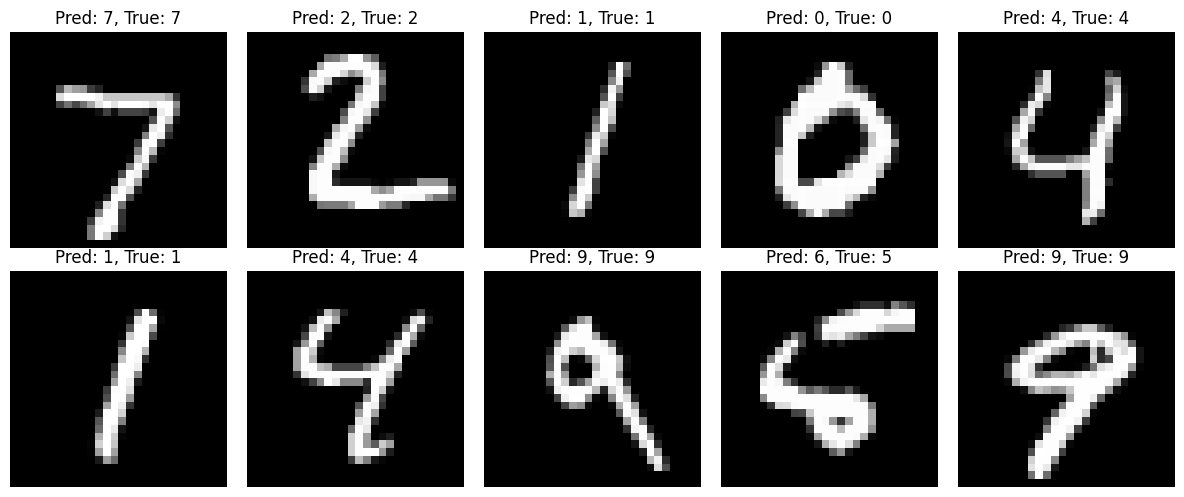

In [40]:
import matplotlib.pyplot as plt

# Get a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predictions = torch.max(outputs, 1)

# Move to CPU for plotting
images = images.cpu()
predictions = predictions.cpu()
labels = labels.cpu()

# Plot first 10 images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Pred: {predictions[i]}, True: {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 10. Summary and Best Practices

### Key Takeaways

1. **Tensors** are the fundamental data structure in PyTorch
   - Similar to NumPy arrays but GPU-enabled
   - Support automatic differentiation

2. **Autograd** computes gradients automatically
   - Use `requires_grad=True` to track operations
   - Call `.backward()` to compute gradients
   - Remember to zero gradients!

3. **Neural Networks** are built with `nn.Module`
   - Define layers in `__init__`
   - Implement forward pass in `forward()`
   - Use built-in loss functions and optimizers

### Best Practices

#### 1. Device Management
```python
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data = data.to(device)
```

#### 2. Training Loop Pattern
```python
model.train()  # Training mode
for images, labels in train_loader:
    optimizer.zero_grad()      # Clear gradients
    outputs = model(images)    # Forward pass
    loss = criterion(outputs, labels)
    loss.backward()            # Backward pass
    optimizer.step()           # Update weights
```

#### 3. Evaluation Mode
```python
model.eval()  # Evaluation mode
with torch.no_grad():  # Disable gradient computation
    outputs = model(test_data)
```

#### 4. Save and Load Models
```python
# Save
torch.save(model.state_dict(), 'model.pth')

# Load
model.load_state_dict(torch.load('model.pth'))
```

### Common Pitfalls to Avoid

❌ **Forgetting to zero gradients**
```python
# Wrong - gradients accumulate!
loss.backward()
optimizer.step()
```
✅ **Correct**
```python
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

❌ **Model and data on different devices**
```python
model = model.to('cuda')
output = model(data)  # data still on CPU - Error!
```
✅ **Correct**
```python
model = model.to(device)
data = data.to(device)
output = model(data)
```

❌ **Forgetting to call `.eval()` during testing**
```python
# Wrong - dropout/batchnorm still active
with torch.no_grad():
    output = model(test_data)
```
✅ **Correct**
```python
model.eval()
with torch.no_grad():
    output = model(test_data)
```

## 11. Practice Exercises

### Exercise 1: Implement Additional Vector Operations

Implement these functions using PyTorch:
1. **Sum-Product**: Sum of all elements in the outer product
2. **ReLU Derivative**: Derivative of ReLU (1 if x > 0, else 0)
3. **Sigmoid**: $\sigma(x) = \frac{1}{1 + e^{-x}}$

In [41]:
# Exercise 1.1: Sum-Product
def sum_product(x, y):
    """
    Sum of all elements in outer product.
    Hint: Combine outer product with .sum()
    """
    # YOUR CODE HERE
    pass

# Test
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0])
# Expected: (1+2+3) * (4+5) = 6 * 9 = 54
# print(f"Result: {sum_product(x, y)}")

In [42]:
# Exercise 1.2: ReLU Derivative
def relu_derivative(x):
    """
    Derivative of ReLU: 1 if x > 0, else 0
    Hint: Use comparison operators and .float()
    """
    # YOUR CODE HERE
    pass

# Test
x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
# Expected: [0, 0, 0, 1, 1]
# print(f"Result: {relu_derivative(x)}")

In [43]:
# Exercise 1.3: Sigmoid
def sigmoid(x):
    """
    Sigmoid activation: 1 / (1 + exp(-x))
    Hint: Use torch.exp()
    """
    # YOUR CODE HERE
    pass

# Test
x = torch.tensor([0.0, 1.0, -1.0])
# Expected: [0.5, 0.731, 0.269] (approximately)
# print(f"Result: {sigmoid(x)}")

### Exercise 2: Build a Deeper Network

Modify the SimpleNN to add:
1. Another hidden layer (128 → 64 neurons)
2. Dropout for regularization
3. Batch normalization

In [44]:
class ImprovedNN(nn.Module):
    def __init__(self):
        super(ImprovedNN, self).__init__()
        
        # TODO: Define your layers
        # Hint: Use nn.Linear, nn.Dropout, nn.BatchNorm1d
        pass
    
    def forward(self, x):
        # TODO: Implement forward pass
        pass

# Test your model
# model = ImprovedNN()
# print(model)

### Exercise 3: Experiment with Hyperparameters

Try modifying:
- Learning rate (0.001, 0.01, 0.1)
- Batch size (32, 64, 128)
- Number of epochs (1, 3, 5)
- Optimizer (SGD, Adam, RMSprop)

Track how these affect training speed and final accuracy!

## 12. Additional Resources

### Official Documentation
- [PyTorch Documentation](https://pytorch.org/docs/stable/index.html) - Complete API reference
- [PyTorch Tutorials](https://pytorch.org/tutorials/) - Official tutorials
- [PyTorch Examples](https://github.com/pytorch/examples) - Example implementations

### Learning Resources
- [Deep Learning with PyTorch](https://pytorch.org/assets/deep-learning/Deep-Learning-with-PyTorch.pdf) - Free book
- [PyTorch Lightning](https://www.pytorchlightning.ai/) - High-level framework
- [Papers with Code](https://paperswithcode.com/) - Latest research implementations

### Tools and Libraries
- **torchvision**: Computer vision datasets and models
- **torchaudio**: Audio processing
- **torchtext**: Natural language processing
- **TensorBoard**: Visualization tool

### Important Concepts to Study Next
1. **Convolutional Neural Networks (CNNs)** for image processing
2. **Recurrent Neural Networks (RNNs/LSTMs)** for sequences
3. **Transformers** for modern NLP
4. **Transfer Learning** using pre-trained models
5. **Data Augmentation** for better generalization

### Useful Tips
- Always check tensor shapes when debugging
- Use `print(model)` to verify architecture
- Monitor training with visualization tools
- Start simple, then add complexity
- Read error messages carefully - they're usually helpful!

---

## Good Luck with Your Deep Learning Journey! 🚀

*Remember: Practice is key. Try building different models and experimenting with various datasets!*

## Quick Reference Cheat Sheet

### Tensor Creation
```python
torch.tensor([1, 2, 3])          # From list
torch.zeros(2, 3)                # Zeros
torch.ones(2, 3)                 # Ones
torch.randn(2, 3)                # Random normal
torch.rand(2, 3)                 # Random uniform
```

### Tensor Operations
```python
x + y, x - y, x * y, x / y      # Element-wise ops
x @ y, torch.mm(x, y)           # Matrix multiplication
x.dot(y)                         # Dot product
x.reshape(2, 3)                  # Reshape
x.view(-1)                       # Flatten
```

### Autograd
```python
x = torch.tensor(2.0, requires_grad=True)
y = x**2
y.backward()       # Compute gradients
print(x.grad)      # Access gradient
x.grad.zero_()     # Clear gradient
```

### Neural Network Basics
```python
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(10, 5)
    
    def forward(self, x):
        return self.layer(x)
```

### Common Layers
```python
nn.Linear(in_features, out_features)  # Fully connected
nn.Conv2d(in_ch, out_ch, kernel_size) # 2D convolution
nn.MaxPool2d(kernel_size)             # Max pooling
nn.Dropout(p=0.5)                     # Dropout
nn.BatchNorm1d(num_features)          # Batch norm
```

### Activation Functions
```python
F.relu(x)
F.sigmoid(x)
F.tanh(x)
F.softmax(x, dim=1)
```